In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Load dataset
df = pd.read_csv("/content/hdfc_loan_dataset_full_enriched - hdfc_loan_dataset_full_enriched.csv")

In [6]:
df.head()

,Loan_ID,Bank,Customer_Name,Gender,Married,Dependents,Education,Employment_Status,Applicant_Income,Coapplicant_Income,...,Loan_to_Annual_Income,Customer_Sentiment,Religion,State,City,PIN_Code,Aadhaar_Synthetic,Phone_Number,Email,Occupation
0,HDFC100001,HDFC Bank,Rohan Verma,Male,No,2,Graduate,Salaried,56976,0,...,11.747,Positive,Hindu,Delhi,Dwarka,857743,6.940000e+11,9068671773,rohan.verma@example.in,Farmer
1,HDFC100002,HDFC Bank,Rohan Verma,Male,No,0,Graduate,Unemployed,1856,0,...,40.381,Negative,Hindu,Punjab,Ludhiana,863836,6.330000e+11,9990772625,rohan.verma@example.in,Civil Engineer
2,HDFC100003,HDFC Bank,Aditya Nair,Female,Yes,0,Graduate,Salaried,64553,0,...,3.082,Positive,Hindu,Maharashtra,Nagpur,834796,1.660000e+11,9195085016,aditya.nair@example.in,Medical Representative
3,HDFC100004,HDFC Bank,Ananya Joshi,Male,No,0,Graduate,Salaried,88450,0,...,0.621,Negative,Hindu,Gujarat,Vadodara,438590,5.528183e+10,9179335548,ananya.joshi@example.in,Marketing Executive
4,HDFC100005,HDFC Bank,Harpreet Singh,Male,Yes,3,Graduate,Self-Employed,9539,0,...,1.736,Neutral,Sikh,West Bengal,Kolkata,495224,1.560000e+11,9795137116,harpreet.singh@example.in,Shopkeeper


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 47 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Loan_ID                      1000 non-null   object 
 1   Bank                         1000 non-null   object 
 2   Customer_Name                1000 non-null   object 
 3   Gender                       1000 non-null   object 
 4   Married                      1000 non-null   object 
 5   Dependents                   1000 non-null   int64  
 6   Education                    1000 non-null   object 
 7   Employment_Status            1000 non-null   object 
 8   Applicant_Income             1000 non-null   int64  
 9   Coapplicant_Income           1000 non-null   int64  
 10  Loan_Amount                  1000 non-null   int64  
 11  Loan_Term_Months             1000 non-null   int64  
 12  Credit_History               1000 non-null   int64  
 13  Property_Area      

In [8]:
# Making a copy of columns to create a new dataframe
new_df = df[["Applicant_Income","Annual_Household_Income","CIBIL_Score","Debt_to_Income_Ratio","Loan_Status"]].copy()
new_df.reset_index()
new_df.head()

,Applicant_Income,Annual_Household_Income,CIBIL_Score,Debt_to_Income_Ratio,Loan_Status
0,56976,683712,699,0.098,Approved
1,1856,22272,707,4.939,Rejected
2,64553,774636,641,0.000,Approved
3,88450,1061400,677,0.301,Approved
4,9539,114468,594,0.000,Approved


In [9]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Applicant_Income         1000 non-null   int64  
 1   Annual_Household_Income  1000 non-null   int64  
 2   CIBIL_Score              1000 non-null   int64  
 3   Debt_to_Income_Ratio     1000 non-null   float64
 4   Loan_Status              1000 non-null   object 
dtypes: float64(1), int64(3), object(1)
memory usage: 39.2+ KB


In [10]:
# Changing loan_status to numeric form 1, 0
new_df["Loan_Status"] = np.where(df["Loan_Status"] == "Approved",1,0)
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Applicant_Income         1000 non-null   int64  
 1   Annual_Household_Income  1000 non-null   int64  
 2   CIBIL_Score              1000 non-null   int64  
 3   Debt_to_Income_Ratio     1000 non-null   float64
 4   Loan_Status              1000 non-null   int64  
dtypes: float64(1), int64(4)
memory usage: 39.2 KB


In [11]:
new_df.describe()

,Applicant_Income,Annual_Household_Income,CIBIL_Score,Debt_to_Income_Ratio,Loan_Status
count,1000.000000,1.000000e+03,1000.00000,1000.000000,1000.000000
mean,42430.057000,6.258861e+05,653.01300,148.118157,0.653000
std,28133.210769,4.724545e+05,73.83654,1974.599103,0.476254
min,0.000000,0.000000e+00,384.00000,0.000000,0.000000
25%,18260.000000,2.639520e+05,605.75000,0.031000,0.000000
50%,40675.500000,5.512440e+05,654.00000,0.332000,1.000000
75%,61037.250000,8.565480e+05,704.00000,0.795000,1.000000
max,149266.000000,2.555340e+06,878.00000,38342.000000,1.000000


**Overall Approval rate calculation:**

In [12]:

approval_rate = new_df["Loan_Status"].mean()*100
approval_rate

np.float64(65.3)

**Annual debt calculation to find financial indicator and categorize it**

In [13]:
new_df["Annual_debt"] = new_df["Annual_Household_Income"]*new_df["Debt_to_Income_Ratio"]
new_df["financial_indicator"] = np.where(new_df["Loan_Status"] == 0,"Not applicable",
                                         np.where(new_df["Annual_debt"]>new_df["Annual_Household_Income"],"Critical",
                                                  np.where(new_df["Annual_debt"]<new_df["Annual_Household_Income"],"Healthy",
                                                           "Manageabele")))
new_df.head(10)

,Applicant_Income,Annual_Household_Income,CIBIL_Score,Debt_to_Income_Ratio,Loan_Status,Annual_debt,financial_indicator
0,56976,683712,699,0.098,1,67003.776,Healthy
1,1856,22272,707,4.939,0,110001.408,Not applicable
2,64553,774636,641,0.000,1,0.000,Healthy
3,88450,1061400,677,0.301,1,319481.400,Healthy
4,9539,114468,594,0.000,1,0.000,Healthy
5,39184,470208,682,0.469,1,220527.552,Healthy
6,81223,974676,693,0.646,1,629640.696,Healthy
7,0,0,723,712.000,0,0.000,Not applicable
8,17675,212100,593,1.557,0,330239.700,Not applicable
9,71409,856908,538,0.000,1,0.000,Healthy


**Approval rate per person**

In [14]:
new_df["Approval_rate(in %)"] =  np.where(new_df["Annual_debt"]>new_df["Annual_Household_Income"],25,
                                             np.where(new_df["Annual_debt"]<new_df["Annual_Household_Income"],75,
                                                      50))
new_df.head(10)

,Applicant_Income,Annual_Household_Income,CIBIL_Score,Debt_to_Income_Ratio,Loan_Status,Annual_debt,financial_indicator,Approval_rate(in %)
0,56976,683712,699,0.098,1,67003.776,Healthy,75
1,1856,22272,707,4.939,0,110001.408,Not applicable,25
2,64553,774636,641,0.000,1,0.000,Healthy,75
3,88450,1061400,677,0.301,1,319481.400,Healthy,75
4,9539,114468,594,0.000,1,0.000,Healthy,75
5,39184,470208,682,0.469,1,220527.552,Healthy,75
6,81223,974676,693,0.646,1,629640.696,Healthy,75
7,0,0,723,712.000,0,0.000,Not applicable,50
8,17675,212100,593,1.557,0,330239.700,Not applicable,25
9,71409,856908,538,0.000,1,0.000,Healthy,75


**Derivative of approval rate and annual debt**

In [15]:
new_df["dA"] = new_df["Approval_rate(in %)"].diff()
new_df["dX"] = new_df["Annual_debt"].diff()
new_df["dA_dX"] = new_df["dA"]/new_df["dX"]
new_df.head(10)

,Applicant_Income,Annual_Household_Income,CIBIL_Score,Debt_to_Income_Ratio,Loan_Status,Annual_debt,financial_indicator,Approval_rate(in %),dA,dX,dA_dX
0,56976,683712,699,0.098,1,67003.776,Healthy,75,NaN,NaN,NaN
1,1856,22272,707,4.939,0,110001.408,Not applicable,25,-50.0,42997.632,-0.001163
2,64553,774636,641,0.000,1,0.000,Healthy,75,50.0,-110001.408,-0.000455
3,88450,1061400,677,0.301,1,319481.400,Healthy,75,0.0,319481.400,0.000000
4,9539,114468,594,0.000,1,0.000,Healthy,75,0.0,-319481.400,-0.000000
5,39184,470208,682,0.469,1,220527.552,Healthy,75,0.0,220527.552,0.000000
6,81223,974676,693,0.646,1,629640.696,Healthy,75,0.0,409113.144,0.000000
7,0,0,723,712.000,0,0.000,Not applicable,50,-25.0,-629640.696,0.000040
8,17675,212100,593,1.557,0,330239.700,Not applicable,25,-25.0,330239.700,-0.000076
9,71409,856908,538,0.000,1,0.000,Healthy,75,50.0,-330239.700,-0.000151


# Task 1

Perform exploratory analysis.
Study:
- Income distribution
- Credit score distribution
- Approval distribution


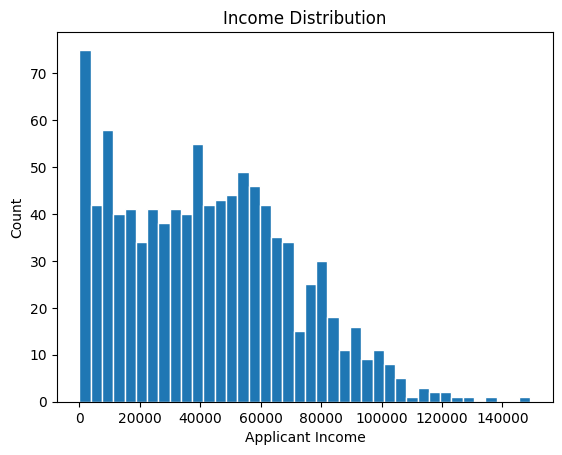

In [16]:
plt.hist(new_df["Applicant_Income"],bins = 40,edgecolor="white")
plt.xlabel("Applicant Income")
plt.ylabel("Count")
plt.title("Income Distribution")
plt.show()

In [17]:
credit_score_bins = [0,550,650,750,np.inf]
credit_score_labels = ["Poor","Fair","Good","Excellent"]
new_df["Credit_Score_Category"] = pd.cut(new_df["CIBIL_Score"],bins = credit_score_bins,labels = credit_score_labels)
new_df.head()

,Applicant_Income,Annual_Household_Income,CIBIL_Score,Debt_to_Income_Ratio,Loan_Status,Annual_debt,financial_indicator,Approval_rate(in %),dA,dX,dA_dX,Credit_Score_Category
0,56976,683712,699,0.098,1,67003.776,Healthy,75,NaN,NaN,NaN,Good
1,1856,22272,707,4.939,0,110001.408,Not applicable,25,-50.0,42997.632,-0.001163,Good
2,64553,774636,641,0.000,1,0.000,Healthy,75,50.0,-110001.408,-0.000455,Fair
3,88450,1061400,677,0.301,1,319481.400,Healthy,75,0.0,319481.400,0.000000,Good
4,9539,114468,594,0.000,1,0.000,Healthy,75,0.0,-319481.400,-0.000000,Fair


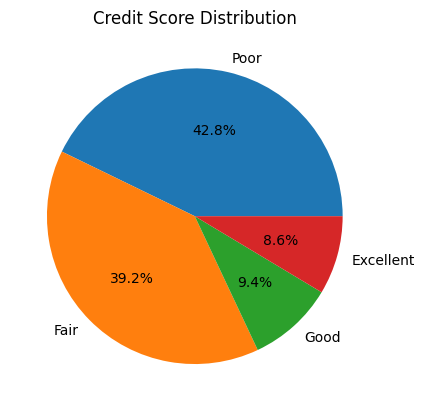

In [18]:
plt.pie(new_df["Credit_Score_Category"].value_counts(),labels = credit_score_labels,autopct = "%1.1f%%")
plt.title("Credit Score Distribution")
plt.show()

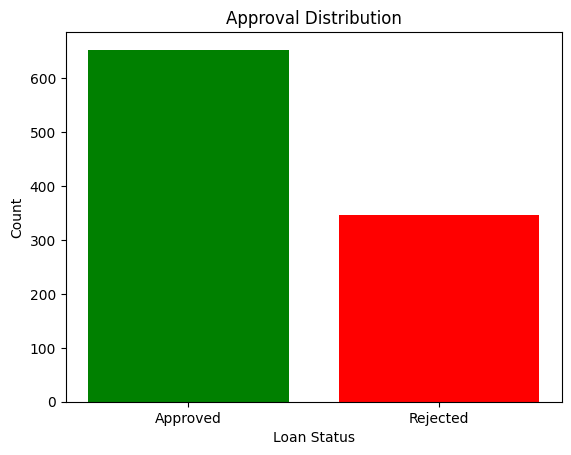

In [19]:
approval = new_df["Loan_Status"].value_counts()
approval_labels = ["Approved","Rejected"]
plt.bar(approval_labels,approval,color = ["green","red"])
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.title("Approval Distribution")
plt.show()

# Task 2
Group applicants into bands.
Example:
- Income Bands

  - Low Income
  - Middle Income
  - High Income
  - Premium Income


In [20]:
# Income bands
Income_bins = [0,25000,50000,75000,np.inf]
Income_labels = ["Low Income","Middle Income","High Income","Premium Income"]
new_df["Income_Category"] = pd.cut(new_df["Applicant_Income"],bins = Income_bins,labels = Income_labels)
new_df.head()

,Applicant_Income,Annual_Household_Income,CIBIL_Score,Debt_to_Income_Ratio,Loan_Status,Annual_debt,financial_indicator,Approval_rate(in %),dA,dX,dA_dX,Credit_Score_Category,Income_Category
0,56976,683712,699,0.098,1,67003.776,Healthy,75,NaN,NaN,NaN,Good,High Income
1,1856,22272,707,4.939,0,110001.408,Not applicable,25,-50.0,42997.632,-0.001163,Good,Low Income
2,64553,774636,641,0.000,1,0.000,Healthy,75,50.0,-110001.408,-0.000455,Fair,High Income
3,88450,1061400,677,0.301,1,319481.400,Healthy,75,0.0,319481.400,0.000000,Good,Premium Income
4,9539,114468,594,0.000,1,0.000,Healthy,75,0.0,-319481.400,-0.000000,Fair,Low Income


# Task 3
Calculate approval rate for each band.


In [21]:
# For Credit Score Category
approval_rate_credit = new_df.groupby("Credit_Score_Category",observed=True)["Approval_rate(in %)"].mean()
approval_rate_credit

,Approval_rate(in %)
Credit_Score_Category,
Poor,60.465116
Fair,65.943878
Good,65.186916
Excellent,64.627660


In [22]:
# For Income Category
approval_rate_income = new_df.groupby("Income_Category",observed=True)["Approval_rate(in %)"].mean()
approval_rate_income

,Approval_rate(in %)
Income_Category,
Low Income,48.411371
Middle Income,69.798658
High Income,74.203187
Premium Income,75.000000


# Task 4
Use numerical differentiation to calculate the rate of change in approval rates.
- Example: np.gradient(approval_rates)


In [23]:
# For credit
gradient_credit = np.gradient(approval_rate_credit)
gradient_credit

array([ 5.47876127,  2.3608998 , -0.65810899, -0.55925631])

In [34]:
credit_dict = dict(zip(credit_score_labels,gradient_credit.data))
credit_dict

{'Poor': 5.4787612719506384,
 'Fair': 2.360899804390346,
 'Good': -0.6581089882761617,
 'Excellent': -0.5592563133823774}

In [25]:
# For Income
gradient_income = np.gradient(approval_rate_income)
gradient_income

array([21.38728648, 12.89590801,  2.60067114,  0.79681275])

In [33]:
Income_dict = dict(zip(Income_labels,gradient_income.data))
Income_dict

{'Low Income': 21.387286480662617,
 'Middle Income': 12.89590800676891,
 'High Income': 2.600671140939596,
 'Premium Income': 0.7968127490039905}

# Task 5
Identify critical thresholds where approval rates increase or decrease sharply.


In [35]:
# How Credit Score differ approval rate on basis of minimum and maximum.
min_credit = gradient_credit.min()
max_credit = gradient_credit.max()
print(f"Minimum Credit Score: {min_credit}") # minimum thresholds value
print(f"Maximum Credit Score: {max_credit}") # maximum thresholds value


Minimum Credit Score: -0.6581089882761617
Maximum Credit Score: 5.4787612719506384


In [36]:
# How Income differ approval rate on basis of minimum and maximum
min_income = gradient_income.min()
max_income = gradient_income.max()
print(f"Minimum Income: {min_income}") # minimum thresholds value
print(f"Maximum Income: {max_income}") # maximum thresholds value

Minimum Income: 0.7968127490039905
Maximum Income: 21.387286480662617


# Visualizations
Create:
## Visual 1
- Income Band vs Approval Rate


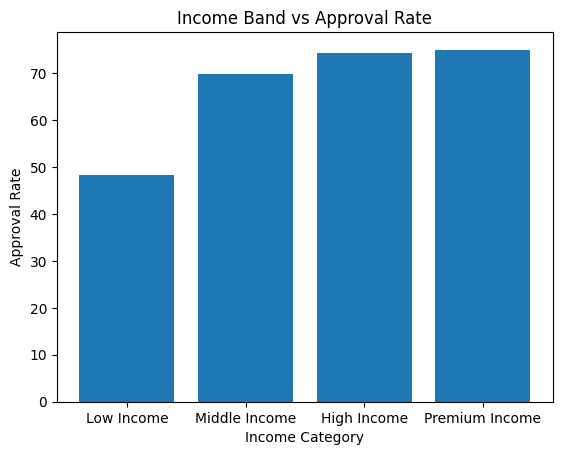

In [27]:
plt.bar(Income_labels,approval_rate_income)
plt.ylabel("Approval Rate")
plt.xlabel("Income Category")
plt.title("Income Band vs Approval Rate")
plt.show()

## Visual 2
- Credit Score Band vs Approval Rate


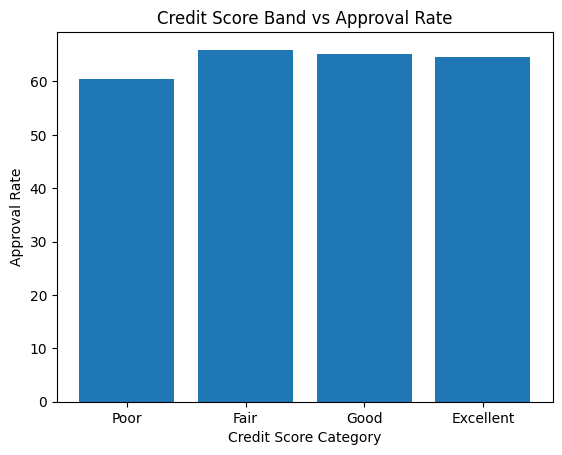

In [28]:
plt.bar(credit_score_labels,approval_rate_credit)
plt.ylabel("Approval Rate")
plt.xlabel("Credit Score Category")
plt.title("Credit Score Band vs Approval Rate")
plt.show()

## Visual 3
- Rate of Change Curve


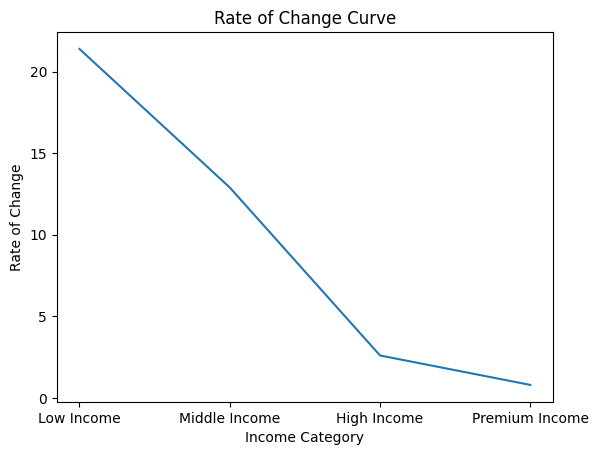

In [29]:
plt.plot(Income_labels,gradient_income)
plt.ylabel("Rate of Change")
plt.xlabel("Income Category")
plt.title("Rate of Change Curve")
plt.show()

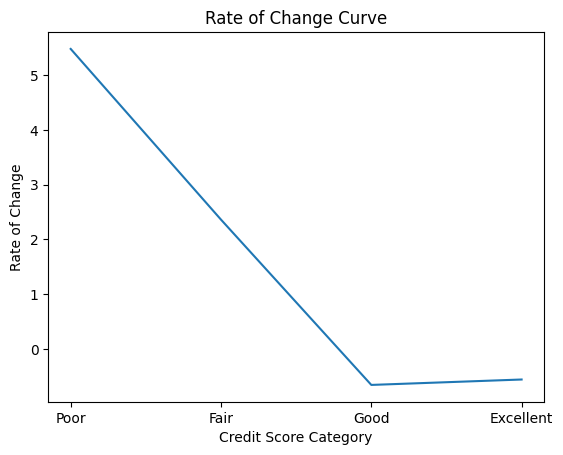

In [30]:
plt.plot(credit_score_labels,gradient_credit)
plt.ylabel("Rate of Change")
plt.xlabel("Credit Score Category")
plt.title("Rate of Change Curve")
plt.show()

# Visual 4
- Feature Sensitivity Comparison


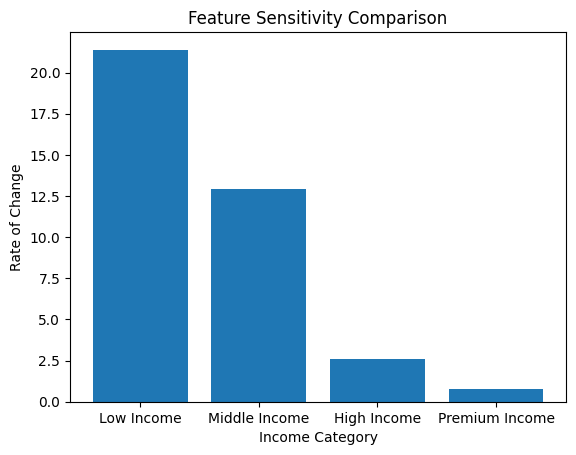

In [31]:
plt.bar(Income_labels,gradient_income)
plt.ylabel("Rate of Change")
plt.xlabel("Income Category")
plt.title("Feature Sensitivity Comparison")
plt.show()

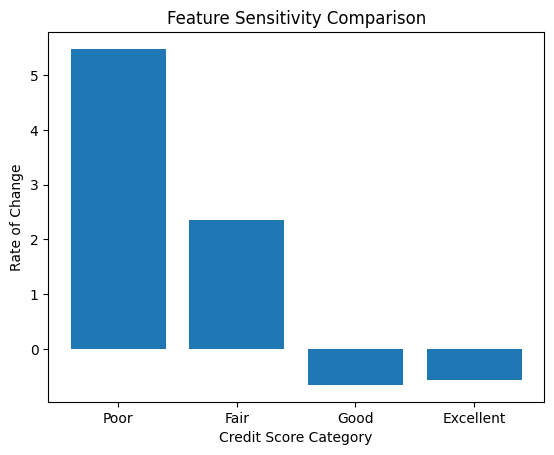

In [32]:
plt.bar(credit_score_labels,gradient_credit)
plt.ylabel("Rate of Change")
plt.xlabel("Credit Score Category")
plt.title("Feature Sensitivity Comparison")
plt.show()